# 00 — EPANET corpus survey

Read-only census of `data/00_networks/`. Nothing here writes to the network files or
touches the fedwater pipelines; outputs land in `data/08_reporting/network_survey/`.

All logic lives in `network_survey.py` so it can become a Kedro node later without a
rewrite. This notebook is the driver and the report.

**Two tiers.**
- *Static census* — no solver, milliseconds per network. Sections, components, IDs,
  patterns, topology, capacity sums.
- *Smoke test* — one solve at the file's own duration (`as_authored`) and one forced
  24 h run (`extended`). Both are cheap (< 5 s per network here) so both are on by
  default. They are separate rows because most of this corpus ships `Duration 0`;
  a file that is fine as authored and catastrophic when extended is not broken, it
  simply has no operating controls for a time series.
- *Capacity bisection* (`run_capacity=True`) — repeated solves to find the largest
  demand multiplier that respects a pressure floor. Off by default.

**Read the two-reader rule.** wntr says what we would simulate; a raw section scan says
what is in the file. Divergences are rows in `issues`, never silent losses.

**Districts.** Some files carry `[TAGS]` node groups (DMA labels from the original
modeller). Those are recorded in the `groups` table for assessment only — they are not
the federated districts, which get assigned later by their own procedure.

In [5]:
import glob
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd()))          # or wherever network_survey.py lives
import network_survey as ns

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 200)
warnings.simplefilter("ignore")               # wntr chatters; real ones land in `issues`

NETWORK_DIR = Path("../../data/00_networks")
OUT_DIR = Path("data/08_reporting/network_survey")
README = NETWORK_DIR / "datasets_readme.txt"

# Subset to survey. None = every .inp in NETWORK_DIR.
SUBSET = None
# SUBSET = ["ky15", "D_Town"]

CFG = ns.SurveyConfig(
    run_smoke=True,          # tier 1b
    run_capacity=True,      # tier 2 — repeated solves, turn on deliberately
    smoke_duration_h=24,
    pressure_floor_m=15.0,
    pressure_band_m=(10.0, 50.0),
    emit_elements=True,
    emit_element_attrs=True,
)

files = sorted(NETWORK_DIR.glob("*.inp"))
if SUBSET:
    files = [f for f in files if f.stem in SUBSET]
print(f"{len(files)} networks: {', '.join(f.stem for f in files)}")
CFG

21 networks: Balerma, C_Town, D_Town, ky1, ky10, ky11, ky12, ky13, ky14, ky15, ky16, ky17, ky18, ky2, ky3, ky4, ky5, ky6, ky7, ky8, ky9


SurveyConfig(emit_elements=True, emit_element_attrs=True, run_smoke=True, smoke_duration_h=24, smoke_timestep_s=3600, pressure_floor_m=15.0, pressure_band_m=(10.0, 50.0), run_capacity=True, capacity_multiplier_hi=25.0, capacity_tol=0.02, capacity_max_iter=14, velocity_ceiling_ms=1.5, max_nodes_for_diameter=2000, artificial_prefix_patterns=('^[IO]-', '^[IO]_'))

## 1. Single-network deep dive

Start here when adding a new file to the corpus, or when the batch flags something.
`survey_network` also returns the live objects under `_wn`, `_junctions` and `_graph`
for ad-hoc poking.

In [6]:
FOCUS = "ky15"

one = ns.survey_network(NETWORK_DIR / f"{FOCUS}.inp", CFG)
for name, df in one.items():
    if not name.startswith("_"):
        print(f"{name:16s} {df.shape}")
one["inventory"].T

inventory        (1, 51)
options          (73, 5)
sections         (28, 5)
components       (9, 7)
elements         (1372, 11)
element_attrs    (7592, 6)
naming           (7, 19)
patterns         (2, 14)
capacity         (13, 6)
topology         (1, 18)
groups           (0, 0)
smoke            (2, 33)
capacity_limit   (1, 5)
issues           (11, 4)


,0
network,ky15
file,ky15.inp
wntr_ok,True
wntr_version,1.3.2
n_bytes,164208
line_ending,CRLF
flow_units_native,GPM
headloss,H-W
demand_model,DDA
demand_multiplier,1.0


In [7]:
# What the file says about itself vs what wntr made of it.
display(one["sections"].sort_values("n_data", ascending=False).head(15))
display(one["components"])
display(one["issues"])

,network,section,n_data,n_comment,occurrences
23,ky15,COORDINATES,669,1,1
4,ky15,PIPES,662,1,1
1,ky15,JUNCTIONS,659,1,1
6,ky15,VALVES,28,1,1
12,ky15,CONTROLS,16,0,1
22,ky15,OPTIONS,16,0,1
5,ky15,PUMPS,13,1,1
20,ky15,TIMES,9,0,1
3,ky15,TANKS,8,1,1
10,ky15,PATTERNS,8,3,1


,network,element_type,count,n_demand_bearing,n_artificial_rule,n_artificial_name,detail
0,ky15,junction,659,565.0,79.0,82.0,
1,ky15,reservoir,2,NaN,NaN,NaN,
2,ky15,tank,8,NaN,NaN,NaN,0 with volume curve
3,ky15,pipe,662,NaN,NaN,NaN,0 initially closed
4,ky15,pump,13,NaN,NaN,NaN,POWER:13
5,ky15,valve,28,NaN,NaN,NaN,PRV:28
6,ky15,pattern,2,NaN,NaN,NaN,
7,ky15,curve,0,NaN,NaN,NaN,
8,ky15,control,16,NaN,NaN,NaN,raw [RULES] lines: 0


,network,check,severity,message
0,ky15,duplicate_section,info,[REACTIONS] appears 2 times
1,ky15,section_present,info,[CONTROLS] carries 16 data lines
2,ky15,section_present,info,[STATUS] carries 1 data lines
3,ky15,section_present,info,[ENERGY] carries 4 data lines
4,ky15,steady_state,warn,Duration 0: the file is a single-snapshot mode...
5,ky15,timestep_mismatch,info,pattern_timestep=3600s != hydraulic_timestep=60s
6,ky15,artificial_node_disagreement,info,3 junctions where the topological rule and the...
7,ky15,unused_pattern,info,1 patterns referenced by nothing: ENRG1
8,ky15,ragged_patterns,info,"pattern lengths differ: [23, 24]"
9,ky15,smoke_as_authored,error,8 negative node-hours at CONSUMER junctions (1...


In [8]:
# Naming: how IDs are built, and which junctions are structural artefacts rather
# than consumers. Pump/valve links need two nodes, so modellers insert zero-demand
# junctions (`I-Pump-3`, `O-RV-25`). Those must never become federated clients.
display(one["naming"][["element_type", "n", "top_shape", "top_shape_share",
                       "n_prefix_families", "top_prefixes", "numeric_contiguous",
                       "samples"]])

j = one["_junctions"]
print("junctions:", len(j),
      "| demand-bearing:", int((j.base_demand_lps > 0).sum()),
      "| artificial (topological rule):", int(j.artificial_by_rule.sum()),
      "| artificial (name pattern):", int(j.artificial_by_name.sum()))
display(j[j.artificial_by_rule != j.artificial_by_name].head(10))

,element_type,n,top_shape,top_shape_share,n_prefix_families,top_prefixes,numeric_contiguous,samples
0,junction,659,A-#,0.8741,5,'J-':577 | 'I-RV-':28 | 'O-RV-':28 | 'I-Pump-'...,False,"J-1, J-10, J-100, J-101, J-102"
1,reservoir,2,A-#,1.0000,1,'R-':2,True,"R-1, R-2"
2,tank,8,A-#,1.0000,1,'T-':8,True,"T-1, T-2, T-3, T-4, T-5"
3,pipe,662,A-#,1.0000,1,'P-':662,True,"P-1, P-10, P-100, P-101, P-102"
4,pump,13,~@A-#,1.0000,1,'~@Pump-':13,True,"~@Pump-1, ~@Pump-10, ~@Pump-11, ~@Pump-12, ~@P..."
5,valve,28,~@A-#,0.9643,2,'~@RV-':27 | 'RV-':1,True,"~@RV-1, ~@RV-10, ~@RV-11, ~@RV-12, ~@RV-13"
6,pattern,2,#,0.5000,2,'':1 | 'ENRG':1,False,"11, ENRG1"


junctions: 659 | demand-bearing: 565 | artificial (topological rule): 79 | artificial (name pattern): 82


,node,elevation_m,base_demand_lps,n_demand_categories,demand_patterns,has_demand_pattern,emitter_coefficient,degree,incident_link_types,tag,artificial_by_rule,artificial_by_rule_strict,artificial_by_name
584,I-Pump-4,269.363068,0.0,1,11,True,0.0,4,"Pipe,Pump",None,False,False,True
625,O-Pump-4,269.363068,0.0,1,11,True,0.0,3,"Pipe,Pump",None,False,False,True
629,I-Pump-8,260.366073,0.0,1,11,True,0.0,3,"Pipe,Pump",None,False,False,True


In [9]:
# Patterns, and which element types reference them. EPANET semantics differ per
# component: a demand pattern is only meaningful on a junction, a head pattern only
# on a reservoir, a speed pattern only on a pump. `used_by` makes actual usage
# explicit instead of assumed, and surfaces unused patterns.
display(one["patterns"])
display(one["capacity"])
display(one["topology"].T)
display(one["smoke"].T)

,network,pattern,length,pattern_timestep_s,span_h,min,max,mean,peak_factor,n_users_total,used_by,used_by_junction_demand,used_by_reservoir_head,used_by_pump_speed
0,ky15,11,24,3600.0,24.0,0.209,1.75,0.999542,1.750802,659,junction_demand:659,659,0,0
1,ky15,ENRG1,23,3600.0,23.0,1.000,1.00,1.000000,1.000000,0,UNUSED,0,0,0


,network,metric,value,unit,method,caveat
0,ky15,demand_base_sum,64.719942,L/s,sum of positive base demands over ALL demand c...,
1,ky15,demand_base_sum_with_multiplier,64.719942,L/s,base sum x DEMAND MULTIPLIER (1.0),the multiplier is a global file-level scale an...
2,ky15,demand_base_sum_cmd,5591.803019,m3/day,base sum x multiplier x 86400,comparable to the readme's CMD/MGD claim
3,ky15,demand_pattern_peak,113.259899,L/s,max over pattern steps of sum(base x pattern) ...,
4,ky15,demand_pattern_mean,64.690279,L/s,mean over pattern steps,
5,ky15,demand_pattern_peak_factor,1.750802,-,system peak factor from the patterns as shipped,
6,ky15,storage_usable_volume,8441.166463,m3,sum over tanks of pi/4 d^2 (max_level - min_le...,
7,ky15,storage_hours_of_mean_demand,36.229458,h,usable volume / mean demand,how long storage alone covers demand
8,ky15,reservoir_head_min,295.960800,m,[RESERVOIRS] Head,
9,ky15,reservoir_head_max,370.027200,m,[RESERVOIRS] Head,


,0
network,ky15
n_nodes,669
n_edges,703
n_components,1
largest_component_frac,1.0
n_sources,10
n_reservoirs,2
n_tanks,8
n_junctions_unreachable_from_source,0
unreachable_sample,


,0,1
duration_h,0.0,24.0
converged,True,True
runtime_s,0.164,0.109
error,,
warnings,,
n_nodes,659,659
n_node_hours,659,16475
pressure_min_m,-99.580177,-160.401978
pressure_median_m,62.587185,57.376152
pressure_max_m,294.703796,295.872437


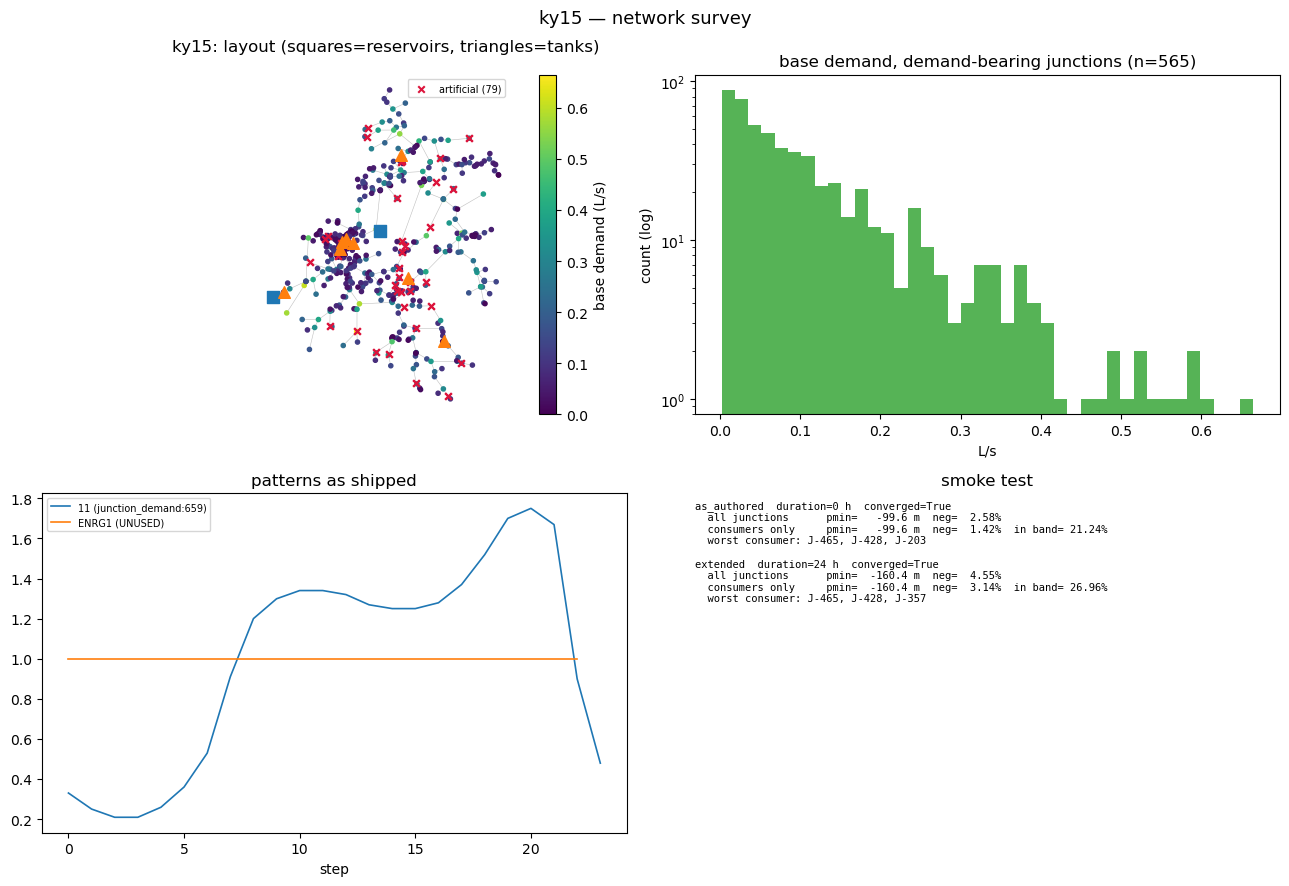

In [10]:
fig = ns.plot_network(one)
OUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_DIR / f"survey_{FOCUS}.png", dpi=140, bbox_inches="tight")
plt.show()

## 2. Batch

A failure on one file is recorded as an `issues` row and never stops the batch.

In [11]:
tables = ns.survey_corpus(files, CFG)
written = ns.write_tables(tables, OUT_DIR)
for p in written:
    print(f"{p}  ({len(pd.read_csv(p)):,} rows)")

  Balerma        4.3s  errors=0
  C_Town         1.1s  errors=1
  D_Town         1.8s  errors=0
  ky1            4.2s  errors=1
  ky10           5.1s  errors=1
  ky11           4.3s  errors=0
  ky12           4.2s  errors=1
  ky13           3.7s  errors=0
  ky14           3.6s  errors=0
  ky15           2.5s  errors=2
  ky16           3.5s  errors=0
  ky17          14.6s  errors=0
  ky18           3.5s  errors=0
  ky2            4.7s  errors=0
  ky3            1.1s  errors=1
  ky4            6.3s  errors=0
  ky5            1.4s  errors=0
  ky6            2.3s  errors=0
  ky7            1.6s  errors=0
  ky8            8.7s  errors=0
  ky9           10.8s  errors=1
data\08_reporting\network_survey\networks_inventory.csv  (21 rows)
data\08_reporting\network_survey\networks_options.csv  (1,570 rows)
data\08_reporting\network_survey\networks_sections.csv  (588 rows)
data\08_reporting\network_survey\networks_components.csv  (189 rows)
data\08_reporting\network_survey\networks_elements.csv  (

In [12]:
inv = tables["inventory"]

# The master view: units and options first, because everything downstream depends
# on them and a hidden DEMAND MULTIPLIER is the classic silent bug.
inv[["network", "flow_units_native", "headloss", "demand_model",
     "demand_multiplier", "duration_h", "hydraulic_timestep_s",
     "pattern_timestep_s", "n_patterns", "n_controls", "n_rules_raw"]]

,network,flow_units_native,headloss,demand_model,demand_multiplier,duration_h,hydraulic_timestep_s,pattern_timestep_s,n_patterns,n_controls,n_rules_raw
0,Balerma,LPS,D-W,DDA,0.45,0.0,3600.0,3600.0,0,0,0
1,C_Town,LPS,H-W,DDA,1.00,0.0,3600.0,3600.0,0,20,0
2,D_Town,LPS,H-W,DDA,1.00,168.0,900.0,3600.0,5,24,0
3,ky1,GPM,H-W,DDA,1.00,0.0,3600.0,3600.0,2,0,0
4,ky10,GPM,H-W,DDA,1.00,0.0,3600.0,3600.0,4,6,0
5,ky11,GPM,H-W,DDA,1.00,0.0,3600.0,3600.0,4,12,0
6,ky12,GPM,H-W,DDA,1.00,0.0,3600.0,3600.0,4,6,0
7,ky13,GPM,H-W,DDA,1.00,0.0,3600.0,3600.0,3,6,0
8,ky14,GPM,H-W,DDA,1.00,0.0,3600.0,3600.0,3,3,0
9,ky15,GPM,H-W,DDA,1.00,0.0,60.0,3600.0,2,16,0


In [13]:
# Component census. n_junctions is NOT the client count: subtract the artificial ones.
inv["n_junctions_consumer"] = inv.n_junctions_demand_bearing - 0  # already excludes zero-demand
inv[["network", "n_junctions", "n_junctions_demand_bearing", "n_junctions_artificial",
     "n_reservoirs", "n_tanks", "n_pipes", "n_pumps", "n_pumps_power_defined",
     "n_valves", "valve_types", "pipe_length_km", "demand_cmd", "storage_m3"]]

,network,n_junctions,n_junctions_demand_bearing,n_junctions_artificial,n_reservoirs,n_tanks,n_pipes,n_pumps,n_pumps_power_defined,n_valves,valve_types,pipe_length_km,demand_cmd,storage_m3
0,Balerma,443,442,0,4,0,454,0,0,0,,100.263,95376.5,0.000000
1,C_Town,388,0,15,1,7,429,11,0,4,PRV | TCV,56.724,0.0,9501.455720
2,D_Town,399,348,13,1,7,443,11,0,5,PRV | TCV,60.417,36483.9,9501.455720
3,ky1,856,797,2,1,2,984,1,1,0,,65.616,7485.3,2154.499933
4,ky10,920,871,34,2,13,1043,13,13,5,PRV,430.026,8184.0,11327.498651
5,ky11,802,694,68,1,28,846,21,21,15,PRV,459.240,6613.4,15503.013594
6,ky12,2347,2246,73,1,7,2426,15,15,22,PRV,648.627,5187.8,6303.346580
7,ky13,778,718,6,2,5,940,4,4,0,,153.298,8928.0,23845.838795
8,ky14,377,331,10,4,3,548,5,5,0,,103.758,3944.8,6832.668245
9,ky15,659,565,79,2,8,662,13,13,28,PRV,482.036,5591.8,8441.166463


In [14]:
# Feasibility. Read the *_consumer columns: sub-atmospheric pressure on an
# artificial pump-suction node is modelling scaffolding, not unserved demand.
inv[["network", "as_authored_converged", "as_authored_pmin_m",
     "as_authored_pmin_m_consumer", "as_authored_frac_negative_consumer",
     "extended_pmin_m_consumer", "extended_frac_negative_consumer"]]

,network,as_authored_converged,as_authored_pmin_m,as_authored_pmin_m_consumer,as_authored_frac_negative_consumer,extended_pmin_m_consumer,extended_frac_negative_consumer
0,Balerma,True,20.001383,20.001383,0.00000,20.001383,0.00000
1,C_Town,True,2.969419,NaN,NaN,NaN,NaN
2,D_Town,True,8.485038,18.090010,0.00000,18.243679,0.00000
3,ky1,True,-108.515038,23.392023,0.00000,-142.285019,0.76000
4,ky10,True,-1.170137,31.215158,0.00000,-118.871429,0.00193
5,ky11,True,-1.778009,22.829174,0.00000,18.377874,0.00000
6,ky12,True,2.640215,25.770872,0.00000,-12.671542,0.00198
7,ky13,True,12.026917,25.365547,0.00000,2.455258,0.00000
8,ky14,True,5.094981,25.002085,0.00000,25.002085,0.00000
9,ky15,True,-99.580177,-99.580177,0.01416,-160.401978,0.03143


In [15]:
# Topology — dead ends, articulation points and bridges constrain any later
# district partition, so they are collected now rather than rediscovered later.
tables["topology"][["network", "n_nodes", "n_edges", "n_components",
                    "largest_component_frac", "n_sources", "degree_mean",
                    "n_dead_ends", "dead_end_frac", "n_articulation_points",
                    "n_bridges", "diameter_hops",
                    "n_junctions_unreachable_from_source"]]

,network,n_nodes,n_edges,n_components,largest_component_frac,n_sources,degree_mean,n_dead_ends,dead_end_frac,n_articulation_points,n_bridges,diameter_hops,n_junctions_unreachable_from_source
0,Balerma,447,454,1,1.0,4,2.031,121,0.2707,257,308,60.0,0
1,C_Town,396,444,1,1.0,8,2.242,78,0.1970,193,220,66.0,0
2,D_Town,407,459,1,1.0,8,2.256,78,0.1916,173,190,66.0,0
3,ky1,859,985,1,1.0,3,2.293,191,0.2224,296,323,69.0,0
4,ky10,935,1059,1,1.0,15,2.265,257,0.2749,366,482,89.0,0
5,ky11,831,880,1,1.0,29,2.118,284,0.3418,413,603,112.0,0
6,ky12,2355,2452,1,1.0,8,2.082,432,0.1834,1212,1458,NaN,0
7,ky13,785,934,1,1.0,7,2.380,269,0.3427,287,383,53.0,0
8,ky14,384,544,1,1.0,7,2.833,58,0.1510,71,83,37.0,0
9,ky15,669,703,1,1.0,10,2.102,186,0.2780,352,449,76.0,0


In [16]:
# The issue ledger, worst first. This is the deliverable that matters most.
iss = tables["issues"]
order = {"error": 0, "warn": 1, "info": 2}
display(iss.assign(rank=iss.severity.map(order))
           .sort_values(["rank", "network"])
           .drop(columns="rank")
           .query("severity != 'info'")
           .reset_index(drop=True))
print(iss.groupby(["severity", "check"]).size().to_string())

,network,check,severity,message
0,C_Town,zero_demand,error,no junction carries any base demand
1,ky1,smoke_extended,error,15143 negative node-hours at CONSUMER junction...
2,ky10,smoke_extended,error,42 negative node-hours at CONSUMER junctions (...
3,ky12,smoke_extended,error,111 negative node-hours at CONSUMER junctions ...
4,ky15,smoke_as_authored,error,8 negative node-hours at CONSUMER junctions (1...
5,ky15,smoke_extended,error,444 negative node-hours at CONSUMER junctions ...
6,ky3,smoke_extended,error,401 negative node-hours at CONSUMER junctions ...
7,ky9,smoke_extended,error,8 negative node-hours at CONSUMER junctions (0...
8,Balerma,wntr_load_warning,warn,Changing the headloss formula from H-W to D-W ...
9,Balerma,demand_multiplier,warn,global DEMAND MULTIPLIER = 0.45 -- scales ever...


severity  check                       
error     smoke_as_authored                1
          smoke_extended                   6
          zero_demand                      1
info      artificial_node_disagreement    11
          demand_without_pattern           1
          duplicate_section               20
          existing_groups                  1
          ragged_patterns                 17
          section_present                 52
          timestep_mismatch                2
          unused_pattern                  18
warn      demand_multiplier                1
          extension_artefact               5
          id_collision_across_types        1
          no_controls                      3
          smoke_as_authored               11
          smoke_extended                   8
          steady_state                    18
          wntr_load_warning                3


In [17]:
# Capacity is a vector, not a number — each row names the method that produced it.
cap = tables["capacity"]
cap.pivot_table(index="network", columns="metric", values="value")[[
    "demand_base_sum", "demand_base_sum_with_multiplier", "demand_pattern_peak",
    "demand_pattern_peak_factor", "storage_usable_volume",
    "storage_hours_of_mean_demand", "pump_installed_power",
    "throughput_mincut", "pipe_length_total"]].round(2)

metric,demand_base_sum,demand_base_sum_with_multiplier,demand_pattern_peak,demand_pattern_peak_factor,storage_usable_volume,storage_hours_of_mean_demand,pump_installed_power,throughput_mincut,pipe_length_total
network,,,,,,,,,
Balerma,2453.10,1103.89,1103.89,1.00,0.00,0.00,NaN,842.44,100.26
C_Town,0.00,0.00,NaN,NaN,9501.46,NaN,NaN,NaN,56.72
D_Town,422.27,422.27,379.47,1.44,9501.46,6.25,NaN,912.99,60.42
ky1,86.64,86.64,86.64,1.00,2154.50,6.91,7.46,620.21,65.62
ky10,94.72,94.72,165.76,1.75,11327.50,33.22,125.28,988.08,430.03
ky11,76.54,76.54,133.95,1.75,15503.01,56.26,262.11,1295.14,459.24
ky12,60.04,60.04,105.08,1.75,6303.35,29.16,425.05,601.97,648.63
ky13,103.33,103.33,180.83,1.75,23845.84,64.10,365.39,1358.99,153.30
ky14,45.66,45.66,79.90,1.75,6832.67,41.57,770.31,1419.79,103.76


## 3. The readme is a claim, not evidence

`datasets_readme.txt` is parsed into structured claims and diffed against the measured
census. Mismatches are the point of this section.

In [18]:
claims = ns.parse_readme(README)
diff = ns.compare_readme(inv, claims, rel_tol=0.10)
claims.to_csv(OUT_DIR / "readme_claims.csv", index=False)
diff.to_csv(OUT_DIR / "readme_diff.csv", index=False)

display(claims[["readme_index", "readme_name", "network", "claim_demand_value",
                "claim_demand_unit", "claim_n_reservoirs", "claim_n_tanks",
                "claim_n_pumps", "claim_pipe_km", "claim_class_hwang"]])
display(diff.query("verdict == 'MISMATCH'").reset_index(drop=True))

,readme_index,readme_name,network,claim_demand_value,claim_demand_unit,claim_n_reservoirs,claim_n_tanks,claim_n_pumps,claim_pipe_km,claim_class_hwang
0,02,Balerma,Balerma,115000.00,CMD,4,NaN,NaN,100.000000,distribution branch
1,06,Graeme (Zhi Jiang),Graeme,484000.00,CMD,1,NaN,NaN,126.000000,transmission dense-loop
2,04,C-TOWN,C_Town,NaN,NaN,1,7.0,11.0,56.700000,distribution hybrid
3,05,D-TOWN,D_Town,NaN,NaN,1,7.0,11.0,60.400000,distribution sparse-grid
4,01,KY 1,ky1,2.00,MGD,1,2.0,NaN,65.339366,distribution sparse-grid
5,02,KY 2,ky2,2.09,MGD,1,3.0,1.0,141.461338,distribution dense-grid
6,03,KY 3,ky3,2.02,MGD,3,3.0,5.0,84.490560,NaN
7,04,KY 4,ky4,1.51,MGD,1,4.0,2.0,260.713728,distribution sparse-grid
8,05,KY 5,ky5,2.28,MGD,4,2.0,9.0,84.168691,distribution sparse-grid
9,06,KY 6,ky6,1.56,MGD,2,3.0,2.0,94.146624,distribution dense-grid


,network,field,claim,measured,rel_diff,verdict
0,Balerma,demand_cmd,115000.000000,95376.500,0.170639,MISMATCH
1,ky5,n_tanks,2.000000,3.000,0.500000,MISMATCH
2,ky5,pipe_length_km,84.168691,96.581,0.147469,MISMATCH
3,ky6,pipe_length_km,94.146624,123.200,0.308597,MISMATCH
4,ky13,n_tanks,7.000000,5.000,0.285714,MISMATCH
5,ky13,demand_cmd,10220.607000,8928.000,0.126471,MISMATCH
6,ky14,n_pumps,6.000000,5.000,0.166667,MISMATCH
7,ky14,demand_cmd,8025.069200,3944.800,0.508440,MISMATCH
8,ky15,n_pumps,16.000000,13.000,0.187500,MISMATCH
9,ky16,demand_cmd,7570.820000,5665.700,0.251640,MISMATCH


## 4. Readiness for federated districting

Not an assignment — an assessment of what each network can support. The consumer count
sets how many clients of usable size are possible; multiple sources are what make an
`isolated` coupling variant physically meaningful; valves and pumps are controllable
boundaries, i.e. a real dependence dial rather than a simulated one; and articulation
points constrain where a partition can cut without severing supply.

In [19]:
K = 5  # target number of federated clients
MIN_PER_CLIENT = 20

topo = tables["topology"].set_index("network")
ready = inv.set_index("network").assign(
    consumers=lambda d: d.n_junctions_demand_bearing,
    consumers_per_client=lambda d: (d.n_junctions_demand_bearing / K).round(1),
    supports_K=lambda d: d.n_junctions_demand_bearing >= K * MIN_PER_CLIENT,
    multi_source=lambda d: d.n_reservoirs > 1,
    controllable_boundaries=lambda d: d.n_valves + d.n_pumps,
    feasible_as_authored=lambda d: d.as_authored_frac_negative_consumer.fillna(1) == 0,
    feasible_extended=lambda d: d.extended_frac_negative_consumer.fillna(1) == 0,
)[["consumers", "consumers_per_client", "supports_K", "n_reservoirs", "multi_source",
   "controllable_boundaries", "n_existing_groups", "feasible_as_authored",
   "feasible_extended", "n_controls", "demand_cmd"]]
ready["n_articulation_points"] = topo.n_articulation_points
ready.to_csv(OUT_DIR / "networks_district_readiness.csv")
ready.sort_values(["feasible_as_authored", "consumers"], ascending=[False, False])

,consumers,consumers_per_client,supports_K,n_reservoirs,multi_source,controllable_boundaries,n_existing_groups,feasible_as_authored,feasible_extended,n_controls,demand_cmd,n_articulation_points
network,,,,,,,,,,,,
ky17,2622,524.4,True,1,False,5,0,True,True,0,19157.7,2476
ky12,2246,449.2,True,1,False,37,0,True,False,6,5187.8,1212
ky8,1257,251.4,True,2,True,4,0,True,True,4,9328.7,443
ky9,1030,206.0,True,4,True,73,0,True,False,10,5075.6,620
ky4,934,186.8,True,1,False,2,0,True,True,2,5672.2,318
ky10,871,174.2,True,2,True,18,0,True,False,6,8184.0,366
ky1,797,159.4,True,1,False,1,0,True,False,0,7485.3,296
ky16,768,153.6,True,3,True,7,0,True,True,6,5665.7,310
ky2,757,151.4,True,1,False,1,0,True,True,2,7909.8,190


In [20]:
# Pre-existing [TAGS] groupings. Recorded for assessment; NOT the federated districts.
g = tables["groups"]
display(g if len(g) else "no [TAGS] groups in this subset")

,network,group_source,group,n_nodes
0,D_Town,TAGS,DMA1,132
1,D_Town,TAGS,DMA2,111
2,D_Town,TAGS,DMA3,36
3,D_Town,TAGS,DMA4,54
4,D_Town,TAGS,DMA5,47


## 5. Tier 2 — capacity bisection (opt-in)

The largest global demand multiplier that keeps consumer pressure at or above the floor.
This is the only defensible scalar answer to "maximum capacity"; the static sums above
are inputs, not capacity. Costs ~`capacity_max_iter` solves per network, so it is run
on a chosen subset rather than the whole corpus.

Networks that are already infeasible at their own multiplier return `NaN` — there is no
headroom to bisect.

In [21]:
RUN_TIER2 = False
TIER2_SUBSET = ["D_Town", "ky14", "ky16"]

if RUN_TIER2:
    cfg2 = ns.SurveyConfig(**{**CFG.__dict__, "run_capacity": True})
    t2 = ns.survey_corpus([NETWORK_DIR / f"{n}.inp" for n in TIER2_SUBSET], cfg2)
    t2["capacity_limit"].to_csv(OUT_DIR / "networks_capacity_limit.csv", index=False)
    display(t2["capacity_limit"])
else:
    print("tier 2 skipped — set RUN_TIER2 = True")

tier 2 skipped — set RUN_TIER2 = True


## 6. Per-element tables

`networks_elements.csv` is one row per element (common core only);
`networks_element_attrs.csv` is long, one row per (element, attribute), because EPANET
attributes are type-specific and a flat wide table would invent meaningless N/A cells.
Pivot per type when you need a wide view.

In [22]:
el, at = tables["elements"], tables["element_attrs"]
print(f"elements {el.shape}, attrs {at.shape}")
display(el.groupby(["network", "element_type"]).size().unstack(fill_value=0))

def wide(element_type, network=None):
    """Pivot the long attribute table into a wide per-type frame."""
    q = at[at.element_type == element_type]
    if network:
        q = q[q.network == network]
    num = q.pivot_table(index=["network", "id"], columns="attribute",
                        values="value_num", aggfunc="first")
    txt = q[q.value_num.isna()].pivot_table(index=["network", "id"], columns="attribute",
                                            values="value", aggfunc="first")
    return num.join(txt, how="outer", rsuffix="_str")

display(wide("pump").head(15))
display(wide("tank").head(10))

elements (46741, 11), attrs (258991, 6)


element_type,junction,pipe,pump,reservoir,tank,valve
network,,,,,,
Balerma,443,454,0,4,0,0
C_Town,388,429,11,1,7,4
D_Town,399,443,11,1,7,5
ky1,856,984,1,1,2,0
ky10,920,1043,13,2,13,5
ky11,802,846,21,1,28,15
ky12,2347,2426,15,1,7,22
ky13,778,940,4,2,5,0
ky14,377,548,5,4,3,0


attribute     n_curve_points  power_kW  rated_flow_lps  rated_head_m  shutoff_head_m curve initial_status n_curve_points_str power_kW_str pump_type rated_flow_lps_str rated_head_m_str shutoff_head_m_str speed_pattern
network id                                                                                                                                                                                                              
C_Town  PU1              3.0       NaN            67.0          62.0            86.0     8           Open                NaN          nan      HEAD                NaN              NaN                NaN              
        PU10             3.0       NaN            33.0          62.0           111.0    11           Open                NaN          nan      HEAD                NaN              NaN                NaN              
        PU11             3.0       NaN            33.0          62.0           111.0    11           Open                NaN          nan      HEAD                NaN              NaN                NaN              
        PU2              3.0       NaN            67.0          62.0            86.0     8           Open                NaN          nan      HEAD                NaN              NaN                NaN              
        PU3              3.0       NaN            67.0          62.0            86.0     8           Open                NaN          nan      HEAD                NaN              NaN                NaN              
        PU4              3.0       NaN            33.0          86.0           111.0     9           Open                NaN          nan      HEAD                NaN              NaN                NaN              
        PU5              3.0       NaN            33.0          86.0           111.0     9           Open                NaN          nan      HEAD                NaN              NaN                NaN              
        PU6              3.0       NaN            33.0         136.0           148.0    10           Open                NaN          nan      HEAD                NaN              NaN                NaN              
        PU7              3.0       NaN            33.0         136.0           148.0    10           Open                NaN          nan      HEAD                NaN              NaN                NaN              
        PU8              3.0       NaN            33.0          86.0           111.0     9           Open                NaN          nan      HEAD                NaN              NaN                NaN              
        PU9              3.0       NaN            33.0          86.0           111.0     9           Open                NaN          nan      HEAD                NaN              NaN                NaN              
D_Town  PU1              3.0       NaN            60.0          50.0            70.0     8         Closed                NaN          nan      HEAD                NaN              NaN                NaN              
        PU10             3.0       NaN            30.0          50.0            90.0    11         Closed                NaN          nan      HEAD                NaN              NaN                NaN              
        PU11             3.0       NaN            30.0          50.0            90.0    11         Closed                NaN          nan      HEAD                NaN              NaN                NaN              
        PU2              3.0       NaN            60.0          50.0            70.0     8           Open                NaN          nan      HEAD                NaN              NaN                NaN

attribute   diameter_m  elevation_m  init_level_m  max_level_m  min_level_m  min_vol_m3  usable_volume_m3 vol_curve
network id                                                                                                         
C_Town  T1       31.30         71.5           3.0         6.50          0.0         0.0       5001.403724          
        T2       20.78         65.0           0.5         5.90          0.0         0.0       2000.934993          
        T3       13.73        112.9           3.0         6.75          0.0         0.0        999.389377          
        T4       11.64        132.5           2.5         4.70          0.0         0.0        500.142430          
        T5       11.89        105.8           1.0         4.50          0.0         0.0        499.650245          
        T6        8.33        101.5           5.2         5.50          0.0         0.0        299.738530          
        T7        7.14        102.0           2.5         5.00          0.0         0.0        200.196421          
D_Town  T1       31.30         71.5           3.0         6.50          0.0         0.0       5001.403724          
        T2       20.78         65.0           0.5         5.90          0.0         0.0       2000.934993          
        T3       13.73        112.9           3.0         6.75          0.0         0.0        999.389377